In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries Loaded!")

✅ Libraries Loaded!


In [14]:
df = pd.read_csv('apps.csv')

# Drop the unnamed index column
df = df.drop('Unnamed: 0', axis=1)

print("✅ Dataset Loaded!")
print("Shape:", df.shape)
df.head()

✅ Dataset Loaded!
Shape: (9659, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [15]:
print("=== DATASET INFO ===")
print(df.info())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATES ===")
print("Duplicate rows:", df.duplicated().sum())

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9659 non-null   object 
 1   Category        9659 non-null   object 
 2   Rating          8196 non-null   float64
 3   Reviews         9659 non-null   int64  
 4   Size            8432 non-null   float64
 5   Installs        9659 non-null   object 
 6   Type            9659 non-null   object 
 7   Price           9659 non-null   object 
 8   Content Rating  9659 non-null   object 
 9   Genres          9659 non-null   object 
 10  Last Updated    9659 non-null   object 
 11  Current Ver     9651 non-null   object 
 12  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(1), object(10)
memory usage: 981.1+ KB
None

=== MISSING VALUES ===
App                  0
Category             0
Rating            1463
Reviews              0
Size       

In [16]:
# 1. Drop duplicates
df = df.drop_duplicates()

# 2. Fill missing Rating with median
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

# 3. Fill missing Size with median
df['Size'] = df['Size'].fillna(df['Size'].median())

# 4. Drop rows with missing Current Ver / Android Ver
df = df.dropna(subset=['Current Ver', 'Android Ver'])

# 5. Clean Installs column - remove '+' and ',' and convert to int
df['Installs'] = df['Installs'].str.replace('+', '', regex=False)
df['Installs'] = df['Installs'].str.replace(',', '', regex=False)
df['Installs'] = df['Installs'].astype(int)

# 6. Clean Price column - remove '$' and convert to float
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = df['Price'].astype(float)

# 7. Convert Last Updated to datetime
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

print("✅ Data Cleaned!")
print("Shape after cleaning:", df.shape)
print("Missing values:", df.isnull().sum().sum())
df.head()

✅ Data Cleaned!
Shape after cleaning: (9649, 13)
Missing values: 0


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


In [17]:
print("=== BASIC STATISTICS ===")
print(df.describe())

print("\n=== KEY METRICS ===")
print("Total Apps:", len(df))
print("Average Rating:", round(df['Rating'].mean(), 2))
print("Total Categories:", df['Category'].nunique())
print("Free Apps:", (df['Type'] == 'Free').sum())
print("Paid Apps:", (df['Type'] == 'Paid').sum())

=== BASIC STATISTICS ===
            Rating       Reviews         Size      Installs        Price  \
count  9649.000000  9.649000e+03  9649.000000  9.649000e+03  9649.000000   
mean      4.192476  2.168145e+05    19.344036  7.785404e+06     1.100079   
min       1.000000  0.000000e+00     0.000000  0.000000e+00     0.000000   
25%       4.000000  2.500000e+01     5.300000  1.000000e+03     0.000000   
50%       4.300000  9.690000e+02    12.000000  1.000000e+05     0.000000   
75%       4.500000  2.944500e+04    25.000000  1.000000e+06     0.000000   
max       5.000000  7.815831e+07   100.000000  1.000000e+09   400.000000   
std       0.496528  1.832255e+06    20.589308  5.378557e+07    16.860857   

                        Last Updated  
count                           9649  
mean   2017-10-31 01:35:57.612187648  
min              2010-05-21 00:00:00  
25%              2017-08-08 00:00:00  
50%              2018-05-05 00:00:00  
75%              2018-07-17 00:00:00  
max              

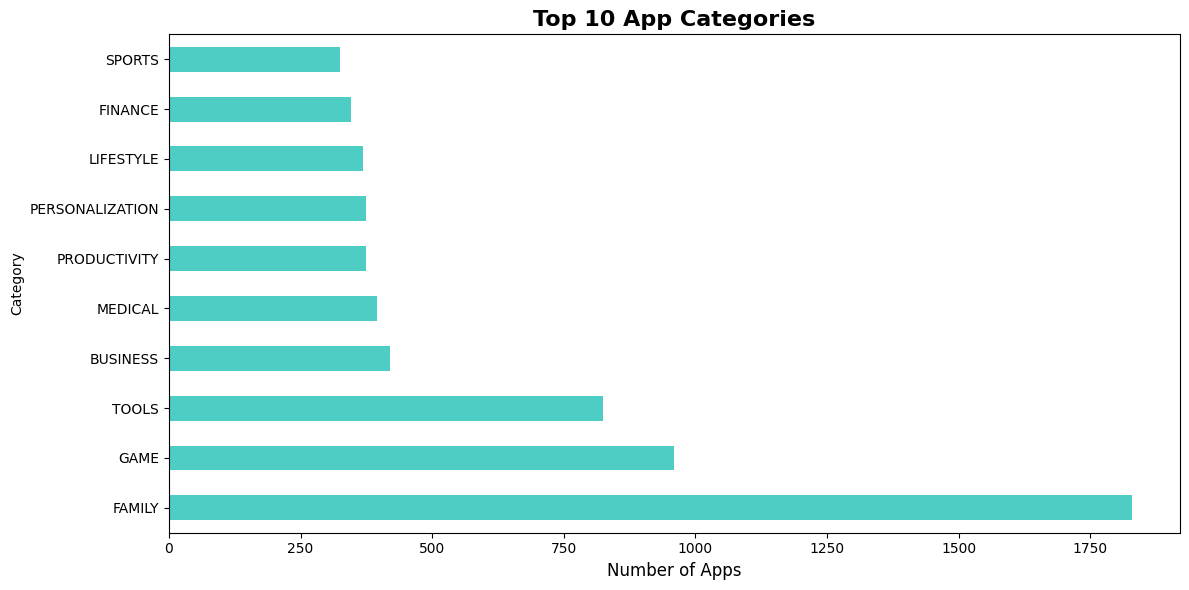

✅ Chart 1 Saved!


In [18]:
plt.figure(figsize=(12,6))
category_count = df['Category'].value_counts().head(10)
category_count.plot(kind='barh', color='#4ECDC4')
plt.title('Top 10 App Categories', fontsize=16, fontweight='bold')
plt.xlabel('Number of Apps', fontsize=12)
plt.tight_layout()
plt.savefig('chart1_category_distribution.png', dpi=150)
plt.show()
print("✅ Chart 1 Saved!")

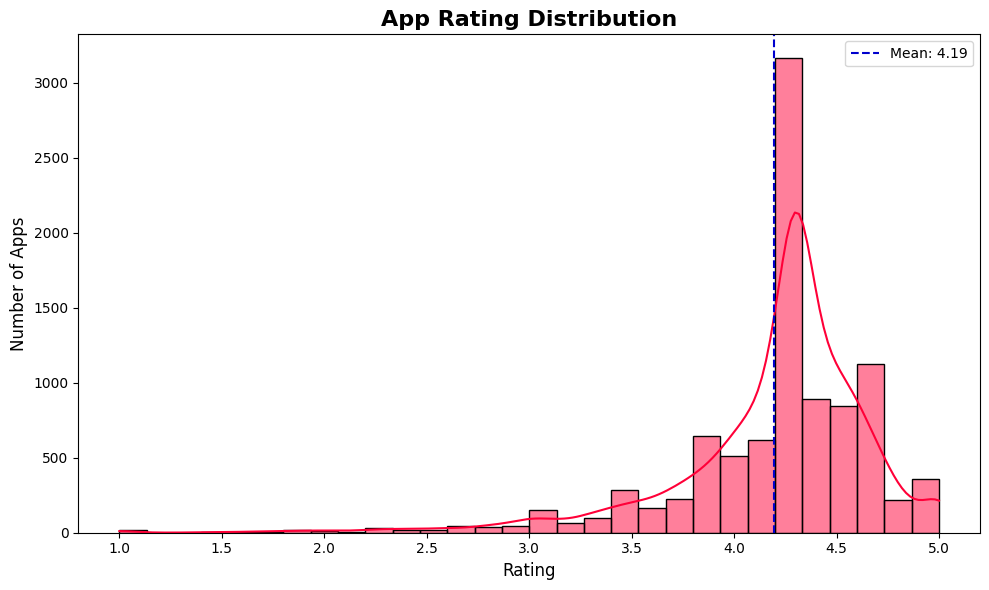

✅ Chart 2 Saved!


In [19]:
plt.figure(figsize=(10,6))
sns.histplot(df['Rating'], bins=30, color='#ff0038', kde=True)
plt.title('App Rating Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Apps', fontsize=12)
plt.axvline(df['Rating'].mean(), color='#0000cd', linestyle='--',
            label=f'Mean: {df["Rating"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('chart2_rating_distribution.png', dpi=150)
plt.show()
print("✅ Chart 2 Saved!")

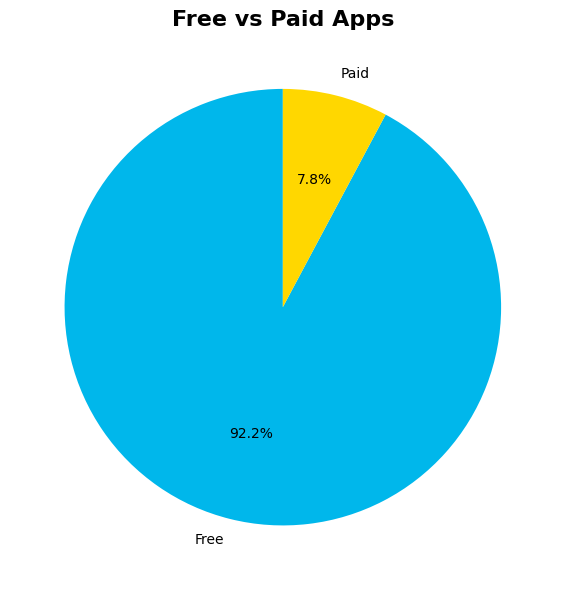

✅ Chart 3 Saved!


In [20]:
plt.figure(figsize=(8,6))
type_count = df['Type'].value_counts()
plt.pie(type_count.values, labels=type_count.index,
        autopct='%1.1f%%', colors=['#00b7eb','#ffd700'], startangle=90)
plt.title('Free vs Paid Apps', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_free_vs_paid.png', dpi=150)
plt.show()
print("✅ Chart 3 Saved!")

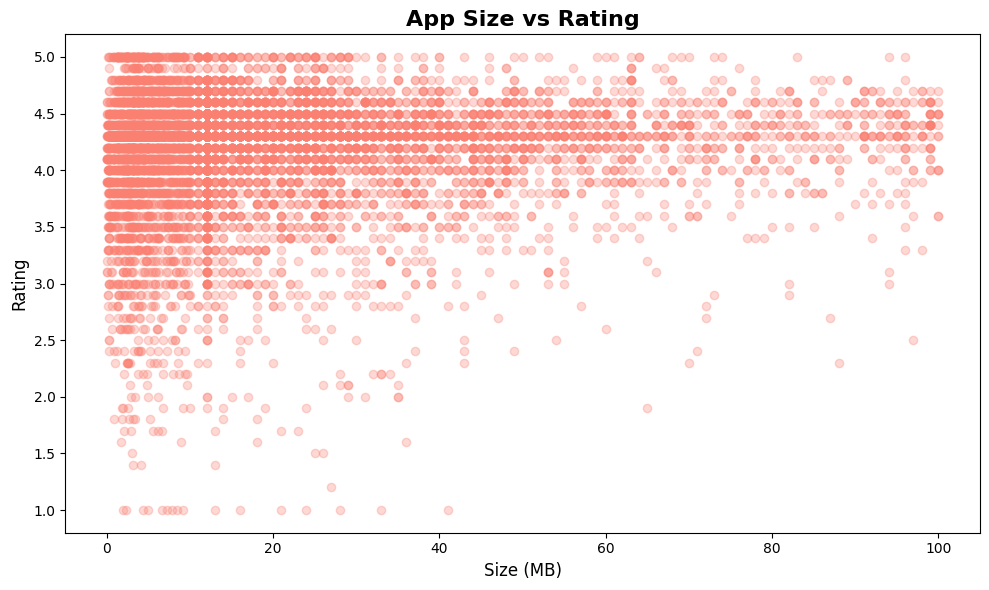

✅ Chart 4 Saved!


In [21]:
plt.figure(figsize=(10,6))
plt.scatter(df['Size'], df['Rating'], alpha=0.3, color='#fa8072')
plt.title('App Size vs Rating', fontsize=16, fontweight='bold')
plt.xlabel('Size (MB)', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.tight_layout()
plt.savefig('chart4_size_vs_rating.png', dpi=150)
plt.show()
print("✅ Chart 4 Saved!")

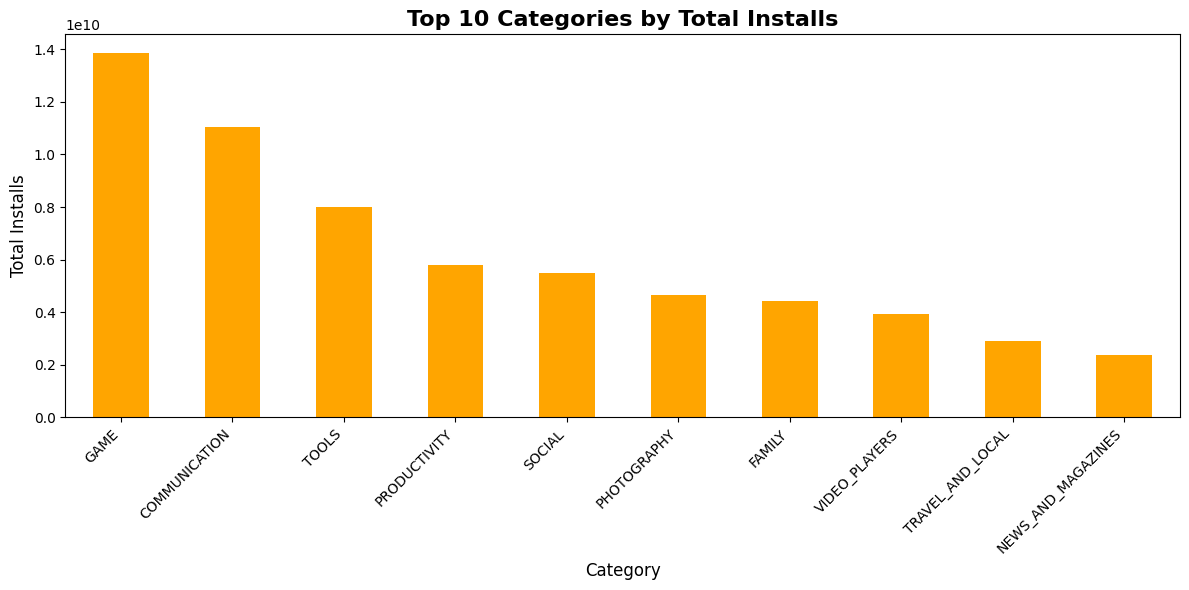

✅ Chart 5 Saved!


In [22]:
plt.figure(figsize=(12,6))
install_by_category = df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)
install_by_category.plot(kind='bar', color='#ffa500')
plt.title('Top 10 Categories by Total Installs', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Installs', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart5_installs_by_category.png', dpi=150)
plt.show()
print("✅ Chart 5 Saved!")

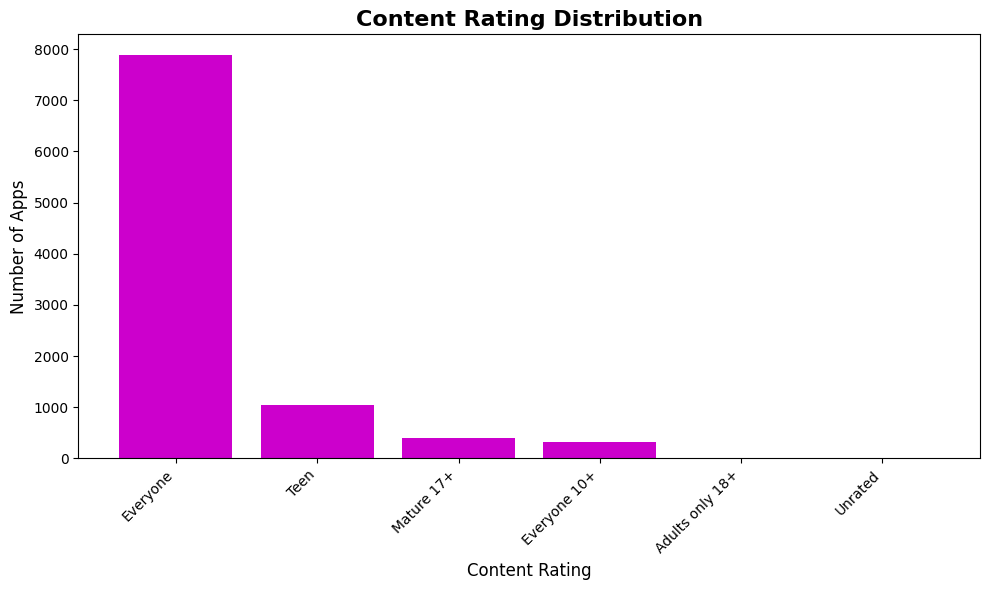

✅ Chart 6 Saved!


In [23]:
plt.figure(figsize=(10,6))
content_count = df['Content Rating'].value_counts()
plt.bar(content_count.index, content_count.values, color='#cc00cc')
plt.title('Content Rating Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Content Rating', fontsize=12)
plt.ylabel('Number of Apps', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart6_content_rating.png', dpi=150)
plt.show()
print("✅ Chart 6 Saved!")

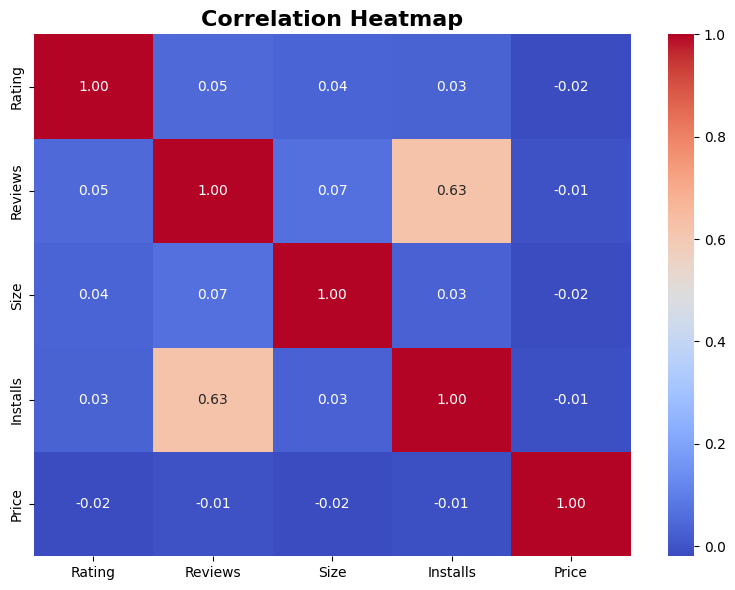

✅ Chart 7 Saved!


In [24]:
plt.figure(figsize=(8,6))
numeric_df = df[['Rating','Reviews','Size','Installs','Price']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_heatmap.png', dpi=150)
plt.show()
print("✅ Chart 7 Saved!")

Shape: (64295, 5)
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']

✅ Reviews data loaded and cleaned!
Sentiment counts:
Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64


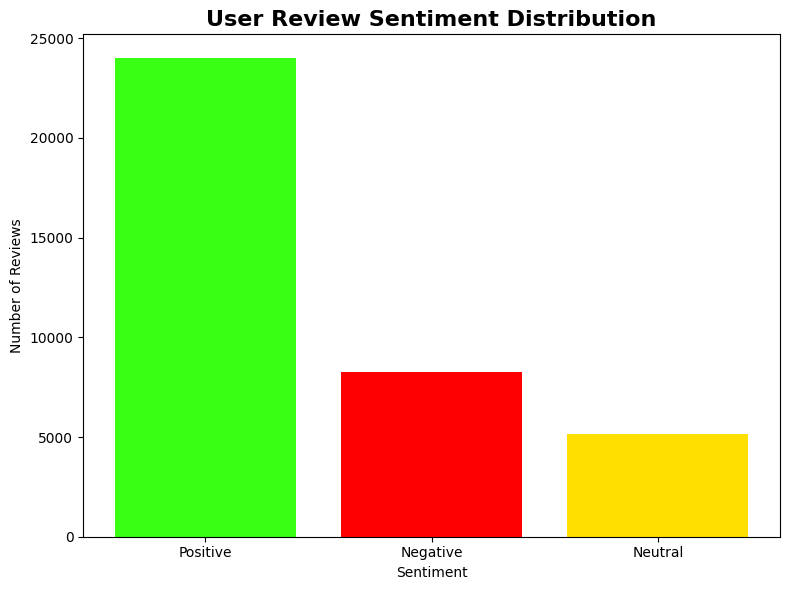

✅ Chart 8 Saved!


In [25]:
# Load second dataset for Sentiment Analysis
reviews_df = pd.read_csv('user_reviews.csv')

print("Shape:", reviews_df.shape)
print(reviews_df.columns.tolist())

# Drop missing values
reviews_df = reviews_df.dropna(subset=['Translated_Review','Sentiment'])

print("\n✅ Reviews data loaded and cleaned!")
print("Sentiment counts:")
print(reviews_df['Sentiment'].value_counts())

# Chart 8: Sentiment Distribution
plt.figure(figsize=(8,6))
sentiment_count = reviews_df['Sentiment'].value_counts()
plt.bar(sentiment_count.index, sentiment_count.values,
        color=['#39ff14','#ff0000','#ffdf00'])
plt.title('User Review Sentiment Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.savefig('chart8_sentiment_distribution.png', dpi=150)
plt.show()
print("✅ Chart 8 Saved!")

In [27]:
print("=" * 50)
print("📊 KEY INSIGHTS & RECOMMENDATIONS")
print("=" * 50)

top_category = df['Category'].value_counts().idxmax()
avg_rating = round(df['Rating'].mean(), 2)
most_installed_cat = df.groupby('Category')['Installs'].sum().idxmax()
free_pct = round((df['Type'] == 'Free').sum() / len(df) * 100, 1)

print(f"\n1. 📱 Most Common Category: {top_category}")
print(f"2. ⭐ Average App Rating: {avg_rating}")
print(f"3. 🏆 Most Installed Category: {most_installed_cat}")
print(f"4. 💰 Free Apps: {free_pct}% of total")

print("\n📌 RECOMMENDATIONS:")
print(f"   → {top_category} is highly saturated - high competition")
print(f"   → Maintain rating above {avg_rating} to stay competitive")
print(f"   → {most_installed_cat} apps have highest reach")
print(f"   → Free model dominates - consider freemium strategy")



📊 KEY INSIGHTS & RECOMMENDATIONS

1. 📱 Most Common Category: FAMILY
2. ⭐ Average App Rating: 4.19
3. 🏆 Most Installed Category: GAME
4. 💰 Free Apps: 92.2% of total

📌 RECOMMENDATIONS:
   → FAMILY is highly saturated - high competition
   → Maintain rating above 4.19 to stay competitive
   → GAME apps have highest reach
   → Free model dominates - consider freemium strategy
